In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
dk_2007_2013 = pd.read_csv("Data/Context/Denmark_2007_2013_last.csv")

dk_2007_2013 = dk_2007_2013.rename({"Unnamed: 0":"Context", "13":"Denmark"}, axis=1)

de_2007_2013 = pd.read_csv("Data/Context/Germany_2007_2013_last.csv")

de_2007_2013 = de_2007_2013.rename({"Unnamed: 0":"Context", "13":"Germany"}, axis=1)

pl_2007_2013 = pd.read_csv("Data/Context/Poland_2007_2013_last.csv")

pl_2007_2013 = pl_2007_2013.rename({"Unnamed: 0":"Context", "13":"Poland"}, axis=1)

lt_2007_2013 = pd.read_csv("Data/Context/Lithuania_2007_2013_last.csv")

lt_2007_2013 = lt_2007_2013.rename({"Unnamed: 0":"Context", "13":"Lithuania"}, axis=1)

lv_2007_2013 = pd.read_csv("Data/Context/Latvia_2007_2013_last.csv")

lv_2007_2013 = lv_2007_2013.rename({"Unnamed: 0":"Context", "13":"Latvia"}, axis=1)

es_2007_2013 = pd.read_csv("Data/Context/Estonia_2007_2013_last.csv")

es_2007_2013 = es_2007_2013.rename({"Unnamed: 0":"Context", "13":"Estonia"}, axis=1)

fi_2007_2013 = pd.read_csv("Data/Context/Finland_2007_2013_last.csv")

fi_2007_2013 = fi_2007_2013.rename({"Unnamed: 0":"Context", "13":"Finland"}, axis=1)

sw_2007_2013 = pd.read_csv("Data/Context/Sweden_2007_2013_last.csv")

sw_2007_2013 = sw_2007_2013.rename({"Unnamed: 0":"Context", "13":"Sweden"}, axis=1)

In [3]:
dk_2007_2013

,Context,Denmark
0,ROL,1.900000
1,GE,1.940000
2,COC,2.400000
3,RQ,1.800000
4,VAA,1.670000
5,CPI,91.000000
6,FOP,0.992000
7,JI,0.989000
8,IUI,94.600000
9,PR,90.000000


In [4]:
all_countries_2007_2013 = dk_2007_2013
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, de_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, pl_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, lt_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, lv_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, es_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, fi_2007_2013, on='Context', how='outer')
all_countries_2007_2013 = pd.merge(all_countries_2007_2013, sw_2007_2013, on='Context', how='outer')

In [5]:
all_countries_2007_2013

,Context,Denmark,Germany,Poland,Lithuania,Latvia,Estonia,Finland,Sweden
0,ROL,1.900000,1.640000,0.840000,0.830000,0.760000,1.190000,1.960000,1.950000
1,GE,1.940000,1.510000,0.660000,0.830000,0.880000,0.970000,2.180000,1.790000
2,COC,2.400000,1.800000,0.650000,0.420000,0.320000,1.180000,2.200000,2.240000
3,RQ,1.800000,1.540000,1.050000,1.150000,1.040000,1.440000,1.840000,1.900000
4,VAA,1.670000,1.410000,1.000000,0.940000,0.770000,1.120000,1.570000,1.660000
5,CPI,91.000000,78.000000,60.000000,57.000000,53.000000,68.000000,89.000000,89.000000
6,FOP,0.992000,0.983000,0.975000,0.957000,0.965000,0.976000,0.985000,0.976000
7,JI,0.989000,0.952000,0.961000,0.974000,0.957000,0.955000,0.981000,0.978000
8,IUI,94.600000,84.200000,62.800000,68.500000,75.200000,80.000000,91.500000,94.800000
9,PR,90.000000,90.000000,60.000000,60.000000,50.000000,85.000000,90.000000,90.000000


In [6]:
all_countries_2007_2013 = all_countries_2007_2013.transpose()

In [7]:
all_countries_2007_2013.columns = all_countries_2007_2013.iloc[0]

In [8]:
all_countries_2007_2013 = all_countries_2007_2013[1:]
all_countries_2007_2013 = all_countries_2007_2013.reset_index()

In [9]:
all_countries_2007_2013 = all_countries_2007_2013.rename({"index":"Country"}, axis =1)

In [10]:
numeric_data = all_countries_2007_2013.drop(columns=['Country'])

In [11]:
labels = all_countries_2007_2013['Country']

In [12]:
all_countries_2007_2013

Context,Country,ROL,GE,COC,RQ,VAA,CPI,FOP,JI,IUI,...,QOMS,CLER,WTDA,DBP,DBD,SSB,DWCP,PMSI,PT,EC
0,Denmark,1.9,1.94,2.4,1.8,1.67,91.0,0.992,0.989,94.6,...,5.15,5.84,6.01,5.0,6.0,91.198876,91.589587,63.333333,91.832348,68.794257
1,Germany,1.64,1.51,1.8,1.54,1.41,78.0,0.983,0.952,84.2,...,5.1,5.2,4.9,9.0,17.5,80.918824,82.870361,50.0,76.740193,76.735165
2,Poland,0.84,0.66,0.65,1.05,1.0,60.0,0.975,0.961,62.8,...,3.96,4.13,3.77,7.0,39.0,79.04043,70.27572,60.0,72.179181,64.976227
3,Lithuania,0.83,0.83,0.42,1.15,0.94,57.0,0.957,0.974,68.5,...,4.37,4.25,3.91,7.0,19.5,84.317188,79.437628,56.666667,81.028515,72.899667
4,Latvia,0.76,0.88,0.32,1.04,0.77,53.0,0.965,0.957,75.2,...,4.38,4.53,3.95,4.0,15.5,91.532399,64.18806,60.0,84.229882,75.590559
5,Estonia,1.19,0.97,1.18,1.44,1.12,68.0,0.976,0.955,80.0,...,4.48,4.94,4.48,5.0,8.5,90.522325,85.428313,56.666667,84.42791,68.759374
6,Finland,1.96,2.18,2.2,1.84,1.57,89.0,0.985,0.981,91.5,...,5.64,5.15,5.74,3.0,17.0,92.36376,77.112896,56.666667,88.088291,73.454375
7,Sweden,1.95,1.79,2.24,1.9,1.66,89.0,0.976,0.978,94.8,...,5.38,5.65,5.94,3.0,16.0,92.263776,79.868963,63.333333,81.946012,68.195515


In [13]:
# labels = all_countries_2007_2013['Context']

In [14]:
sc = StandardScaler()

X = sc.fit_transform(numeric_data)

Number of samples: 8


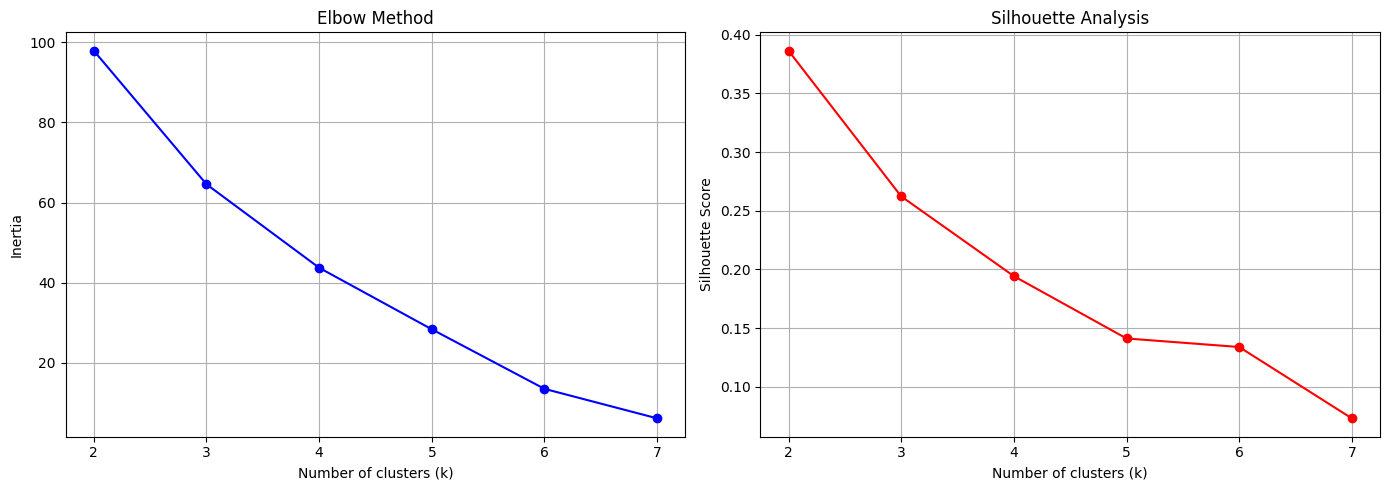

In [15]:
print(f"Number of samples: {len(all_countries_2007_2013)}")

K_range = range(2, 8)  # Maximum k=7 for 8 samples

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [16]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
all_countries_2007_2013['Cluster'] = kmeans.fit_predict(X)

print(f"\n{'='*60}")
print(f"K-Means Clustering Results (k={optimal_k})")
print(f"{'='*60}\n")


K-Means Clustering Results (k=3)



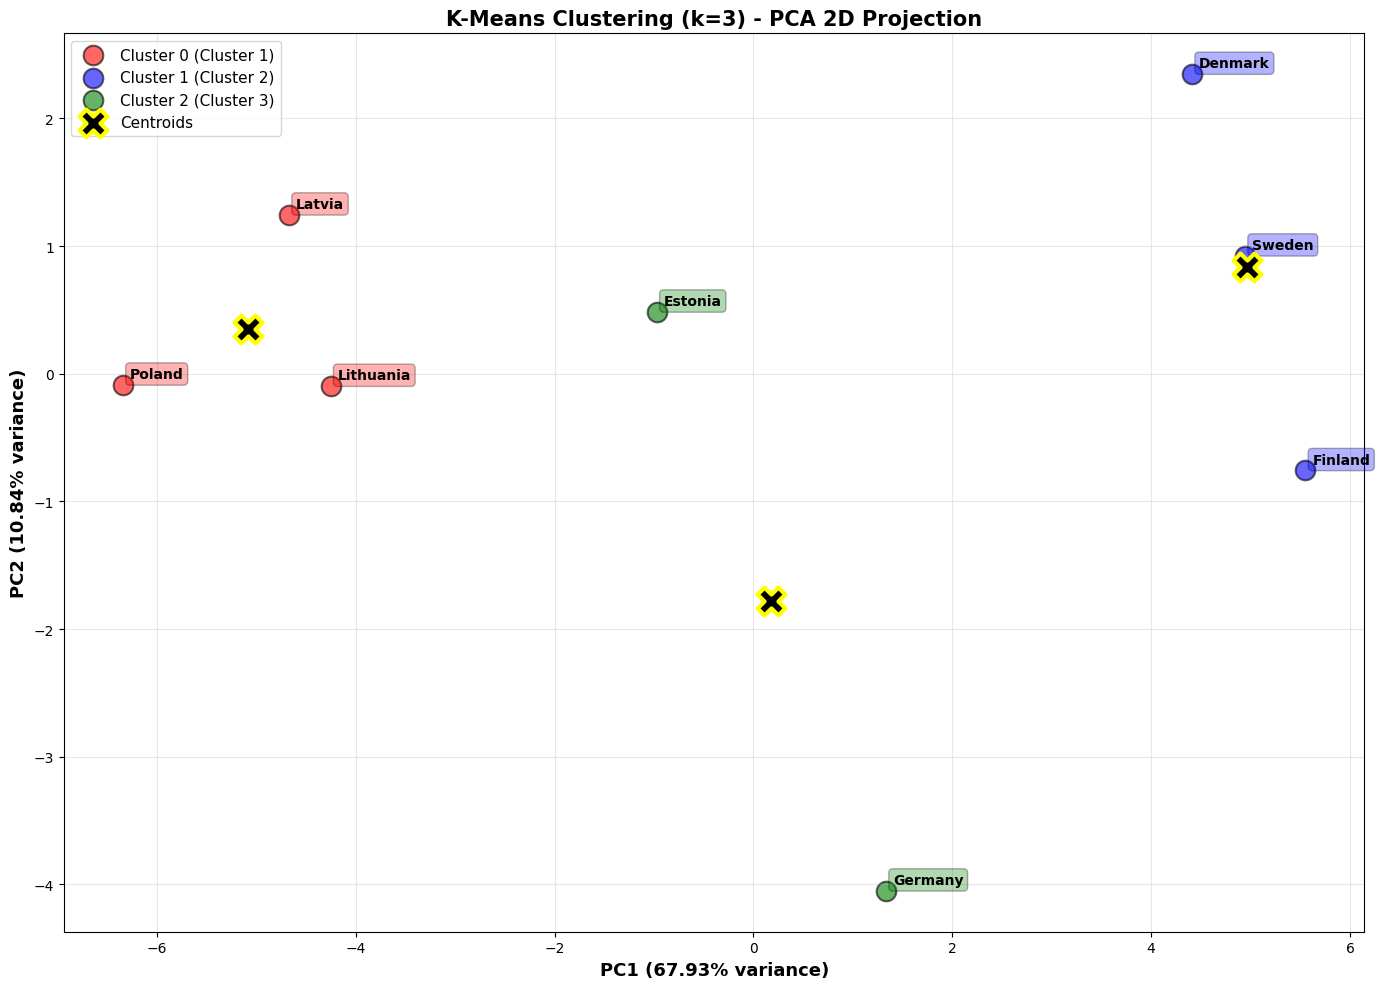


Total variance explained by 2 PCs: 78.77%


In [17]:
colors = ['red', 'blue', 'green']
cluster_country_names = ["Cluster 1", "Cluster 2", "Cluster 3"] 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(14, 10)) 
for i in range(optimal_k):
    cluster_indices = all_countries_2007_2013['Cluster'] == i
    plt.scatter(X_pca[cluster_indices, 0],
                X_pca[cluster_indices, 1],
                c=colors[i],
                label=f'Cluster {i} ({cluster_country_names[i]})',
                s=200, 
                alpha=0.6,
                edgecolors='black',
                linewidth=1.5)
    

    cluster_data = all_countries_2007_2013[cluster_indices]
    for idx, row in cluster_data.iterrows():
        country_idx = all_countries_2007_2013.index.get_loc(idx)
        plt.annotate(row['Country'], 
                    (X_pca[country_idx, 0], X_pca[country_idx, 1]),
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(5, 5), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))


centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=400, edgecolors='yellow',
            linewidths=3, label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection', 
          fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\nTotal variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [18]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

all_countries_2007_2013['Cluster'] = cluster_labels

print("="*60)
print("CLUSTERING STATISTICS")
print("="*60)
print(f"\nNumber of clusters: {optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, cluster_labels):.3f}")

print("\n" + "-"*60)
print("Countries by Cluster:")
print("-"*60)
for cluster in range(optimal_k):
    countries = all_countries_2007_2013[all_countries_2007_2013['Cluster'] == cluster]['Country'].tolist()
    print(f"\nCluster {cluster} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Mean Values)")
print("="*60)

feature_cols = [col for col in all_countries_2007_2013.columns if col not in ['Country', 'Cluster']]

cluster_means = all_countries_2007_2013.groupby('Cluster')[feature_cols].mean()
print("\n", cluster_means.round(2))

print("\n" + "="*60)
print("DEFINING VARIABLES FOR EACH CLUSTER")
print("="*60)

overall_mean = all_countries_2007_2013[feature_cols].mean()
overall_std = all_countries_2007_2013[feature_cols].std()

for cluster in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - Distinctive Characteristics")
    print('='*60)
    
    cluster_data = all_countries_2007_2013[all_countries_2007_2013['Cluster'] == cluster][feature_cols]
    cluster_mean = cluster_data.mean()
    
    z_scores = (cluster_mean - overall_mean) / overall_std
    
    distinctive_features = z_scores.abs().sort_values(ascending=False)
    
    print("\nTop 5 Distinctive Variables:")
    for i, (feature, z_score) in enumerate(z_scores[distinctive_features.index[:5]].items(), 1):
        direction = "HIGH" if z_score > 0 else "LOW"
        print(f"{i}. {feature:10s}: {direction:4s} (z-score: {z_score:+.2f}, "
              f"mean: {cluster_mean[feature]:.2f} vs overall: {overall_mean[feature]:.2f})")



CLUSTERING STATISTICS

Number of clusters: 3
Inertia: 64.56
Silhouette Score: 0.262

------------------------------------------------------------
Countries by Cluster:
------------------------------------------------------------

Cluster 0 (3 countries):
  Poland, Lithuania, Latvia

Cluster 1 (3 countries):
  Denmark, Finland, Sweden

Cluster 2 (2 countries):
  Germany, Estonia

CLUSTER CHARACTERISTICS (Mean Values)

 Context   ROL    GE   COC    RQ   VAA    CPI   FOP    JI    IUI     PR  ...  \
Cluster                                                                 ...   
0        0.81  0.79  0.46  1.08  0.90  56.67  0.97  0.96  68.83  56.67  ...   
1        1.94  1.97  2.28  1.85  1.63  89.67  0.98  0.98  93.63  90.00  ...   
2        1.42  1.24  1.49  1.49  1.27  73.00  0.98  0.95  82.10  87.50  ...   

Context  QOMS  CLER  WTDA   DBP    DBD    SSB   DWCP   PMSI     PT     EC  
Cluster                                                                    
0        4.24  4.30  3.88  6.0

In [19]:
dk_2014_2020 = pd.read_csv("Data/Context/Denmark_2014_2020_last.csv")
de_2014_2020 = pd.read_csv("Data/Context/Germany_2014_2020_last.csv")
pl_2014_2020 = pd.read_csv("Data/Context/Poland_2014_2020_last.csv")
lt_2014_2020 = pd.read_csv("Data/Context/Lithuania_2014_2020_last.csv")
lv_2014_2020 = pd.read_csv("Data/Context/Latvia_2014_2020_last.csv")
es_2014_2020 = pd.read_csv("Data/Context/Estonia_2014_2020_last.csv")
fi_2014_2020 = pd.read_csv("Data/Context/Finland_2014_2020_last.csv")
sw_2014_2020 = pd.read_csv("Data/Context/Sweden_2014_2020_last.csv")

In [20]:
dk_2014_2020 = dk_2014_2020.rename({"Unnamed: 0":"Context", "20":"Denmark"}, axis=1)
de_2014_2020 = de_2014_2020.rename({"Unnamed: 0":"Context", "20":"Germany"}, axis=1)
pl_2014_2020 = pl_2014_2020.rename({"Unnamed: 0":"Context", "20":"Poland"}, axis=1)
lt_2014_2020 = lt_2014_2020.rename({"Unnamed: 0":"Context", "20":"Lithuania"}, axis=1)
lv_2014_2020 = lv_2014_2020.rename({"Unnamed: 0":"Context", "20":"Latvia"}, axis=1)
es_2014_2020 = es_2014_2020.rename({"Unnamed: 0":"Context", "20":"Estonia"}, axis=1)
fi_2014_2020 = fi_2014_2020.rename({"Unnamed: 0":"Context", "20":"Finland"}, axis=1)
sw_2014_2020= sw_2014_2020.rename({"Unnamed: 0":"Context", "20":"Sweden"}, axis=1)

In [21]:
all_countries_2014_2020 = dk_2014_2020
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, de_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, pl_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, lt_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, lv_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, es_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, fi_2014_2020, on='Context', how='outer')
all_countries_2014_2020 = pd.merge(all_countries_2014_2020, sw_2014_2020, on='Context', how='outer')

In [22]:
all_countries_2014_2020 = all_countries_2014_2020.transpose()

In [23]:
all_countries_2014_2020.columns = all_countries_2014_2020.iloc[0]
all_countries_2014_2020 = all_countries_2014_2020[1:]
all_countries_2014_2020 = all_countries_2014_2020.reset_index()
all_countries_2014_2020 = all_countries_2014_2020.rename({"index":"Country"}, axis =1)

In [24]:
all_countries_2014_2020

Context,Country,ROL,GE,COC,RQ,VAA,CPI,FOP,JI,IUI,...,DI,EDBS,DBP,DBD,SSB,DWCP,PMSI,PT,EC,ELFE
0,Denmark,1.81,1.84,2.24,1.79,1.51,88.0,0.988,0.987,96.5,...,9.15,85.225742,5.0,6.0,91.869017,86.940287,72.0,91.142197,73.921002,9.3
1,Germany,1.52,1.31,1.83,1.58,1.37,80.0,0.965,0.919,89.8,...,8.67,79.18023,9.0,13.0,82.24429,78.137981,60.0,82.155389,70.768508,10.1
2,Poland,0.52,0.32,0.62,0.85,0.62,56.0,0.707,0.57,83.2,...,6.85,76.389916,5.0,37.0,82.757531,78.020022,66.0,76.831746,64.363283,5.3
3,Lithuania,0.95,1.01,0.78,1.08,1.0,60.0,0.905,0.967,83.1,...,7.13,81.6297,4.0,5.5,93.273709,84.870297,70.0,88.915657,78.802445,5.6
4,Latvia,0.92,0.84,0.69,1.18,0.87,57.0,0.961,0.963,88.9,...,7.24,80.340843,4.0,5.5,94.114435,73.419157,68.0,89.188135,73.507226,7.2
5,Estonia,1.34,1.3,1.58,1.53,1.17,75.0,0.968,0.933,89.1,...,7.84,80.745858,3.0,5.5,94.661131,82.5036,58.0,89.909583,77.575862,8.5
6,Finland,2.02,1.9,2.17,1.85,1.61,85.0,0.983,0.981,92.2,...,9.2,79.857514,3.0,16.733333,92.473111,73.3994,62.0,90.89746,66.397984,8.2
7,Sweden,1.77,1.67,2.09,1.68,1.5,85.0,0.962,0.974,94.5,...,9.26,81.558564,4.0,7.5,93.111728,78.045257,72.0,85.283436,67.609776,7.7


In [25]:
numeric_data = all_countries_2014_2020.drop(columns=['Country'])

In [26]:
labels = all_countries_2014_2020['Country']

In [27]:
sc = StandardScaler()

X = sc.fit_transform(numeric_data)

Number of samples: 8


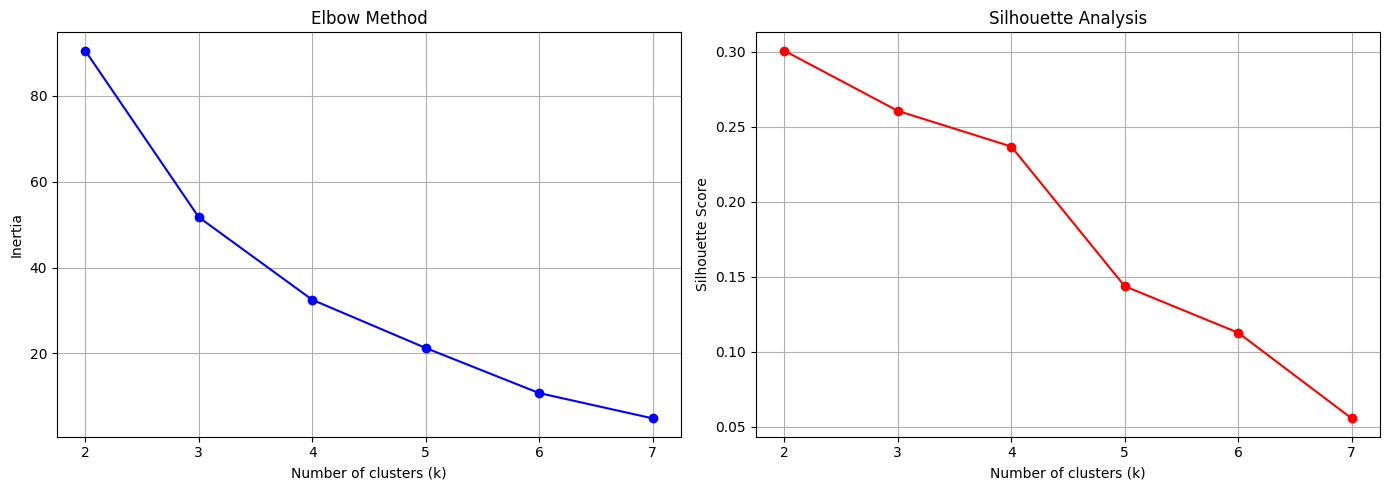

In [28]:
print(f"Number of samples: {len(all_countries_2014_2020)}")

K_range = range(2, 8)  # Maximum k=7 for 8 samples

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [29]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
all_countries_2014_2020['Cluster'] = kmeans.fit_predict(X)

print(f"\n{'='*60}")
print(f"K-Means Clustering Results (k={optimal_k})")
print(f"{'='*60}\n")


K-Means Clustering Results (k=3)



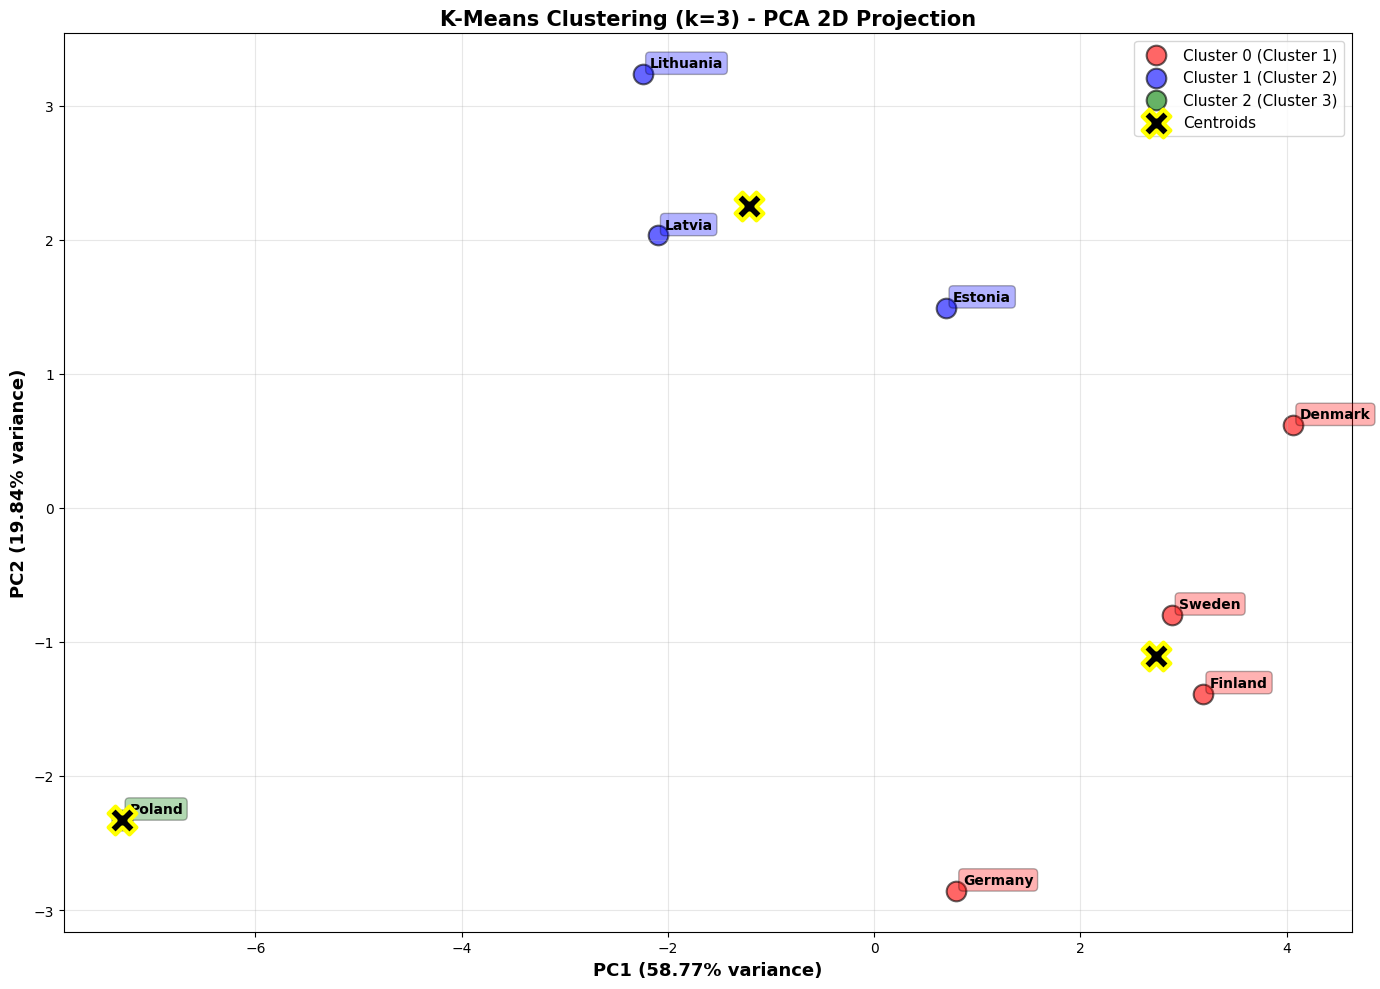


Total variance explained by 2 PCs: 78.60%


In [30]:
colors = ['red', 'blue', 'green']
cluster_country_names = ["Cluster 1", "Cluster 2", "Cluster 3"] 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(14, 10)) 
for i in range(optimal_k):
    cluster_indices = all_countries_2014_2020['Cluster'] == i
    plt.scatter(X_pca[cluster_indices, 0],
                X_pca[cluster_indices, 1],
                c=colors[i],
                label=f'Cluster {i} ({cluster_country_names[i]})',
                s=200, 
                alpha=0.6,
                edgecolors='black',
                linewidth=1.5)
    

    cluster_data = all_countries_2014_2020[cluster_indices]
    for idx, row in cluster_data.iterrows():
        country_idx = all_countries_2014_2020.index.get_loc(idx)
        plt.annotate(row['Country'], 
                    (X_pca[country_idx, 0], X_pca[country_idx, 1]),
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(5, 5), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))


centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=400, edgecolors='yellow',
            linewidths=3, label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection', 
          fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\nTotal variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [31]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

all_countries_2014_2020['Cluster'] = cluster_labels

print("="*60)
print("CLUSTERING STATISTICS")
print("="*60)
print(f"\nNumber of clusters: {optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, cluster_labels):.3f}")

print("\n" + "-"*60)
print("Countries by Cluster:")
print("-"*60)
for cluster in range(optimal_k):
    countries = all_countries_2014_2020[all_countries_2014_2020['Cluster'] == cluster]['Country'].tolist()
    print(f"\nCluster {cluster} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Mean Values)")
print("="*60)

feature_cols = [col for col in all_countries_2014_2020.columns if col not in ['Country', 'Cluster']]

cluster_means = all_countries_2014_2020.groupby('Cluster')[feature_cols].mean()
print("\n", cluster_means.round(2))

print("\n" + "="*60)
print("DEFINING VARIABLES FOR EACH CLUSTER")
print("="*60)

overall_mean = all_countries_2014_2020[feature_cols].mean()
overall_std = all_countries_2014_2020[feature_cols].std()

for cluster in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - Distinctive Characteristics")
    print('='*60)
    
    cluster_data = all_countries_2014_2020[all_countries_2014_2020['Cluster'] == cluster][feature_cols]
    cluster_mean = cluster_data.mean()
    
    z_scores = (cluster_mean - overall_mean) / overall_std
    
    distinctive_features = z_scores.abs().sort_values(ascending=False)
    
    print("\nTop 5 Distinctive Variables:")
    for i, (feature, z_score) in enumerate(z_scores[distinctive_features.index[:5]].items(), 1):
        direction = "HIGH" if z_score > 0 else "LOW"
        print(f"{i}. {feature:10s}: {direction:4s} (z-score: {z_score:+.2f}, "
              f"mean: {cluster_mean[feature]:.2f} vs overall: {overall_mean[feature]:.2f})")



CLUSTERING STATISTICS

Number of clusters: 3
Inertia: 51.72
Silhouette Score: 0.261

------------------------------------------------------------
Countries by Cluster:
------------------------------------------------------------

Cluster 0 (4 countries):
  Denmark, Germany, Finland, Sweden

Cluster 1 (3 countries):
  Lithuania, Latvia, Estonia

Cluster 2 (1 countries):
  Poland

CLUSTER CHARACTERISTICS (Mean Values)

 Context   ROL    GE   COC    RQ   VAA   CPI   FOP    JI    IUI    CFI  ...  \
Cluster                                                                ...   
0        1.78  1.68  2.08  1.72  1.50  84.5  0.97  0.97  93.25  58.38  ...   
1        1.07  1.05  1.02  1.26  1.01  64.0  0.94  0.95  87.03  42.87  ...   
2        0.52  0.32  0.62  0.85  0.62  56.0  0.71  0.57  83.20  40.00  ...   

Context    DI   EDBS   DBP    DBD    SSB   DWCP   PMSI     PT     EC  ELFE  
Cluster                                                                     
0        9.07  81.46  5.25  10.81

===================================================================================================================
===================================================================================================================

In [32]:
common_context = []
for column in all_countries_2007_2013.columns:
    for column_1 in all_countries_2014_2020.columns:
        if column == column_1:
            common_context.append(column)

In [33]:
common_context

['Country',
 'ROL',
 'GE',
 'COC',
 'RQ',
 'VAA',
 'CPI',
 'FOP',
 'JI',
 'IUI',
 'PR',
 'DI',
 'DBP',
 'DBD',
 'SSB',
 'DWCP',
 'PMSI',
 'PT',
 'EC',
 'Cluster']

In [34]:
all_countries_2007_2013_common = all_countries_2007_2013[['Country','ROL', 'GE', 'COC', 'RQ', 'VAA', 'CPI', 'FOP', 
                                                          'JI', 'IUI', 'PR', 'DI', 'DBP', 'DBD', 'SSB', 'DWCP', 
                                                          'PMSI', 'PT', 'EC',]]

In [35]:
all_countries_2014_2020_common = all_countries_2014_2020[['Country','ROL', 'GE', 'COC', 'RQ', 'VAA', 'CPI', 'FOP', 
                                                          'JI', 'IUI', 'PR', 'DI', 'DBP', 'DBD', 'SSB', 'DWCP', 
                                                          'PMSI', 'PT', 'EC',]]

In [36]:
numeric_data = all_countries_2007_2013_common.drop(columns=['Country'])

In [37]:
labels = all_countries_2007_2013_common['Country']

In [38]:
sc = StandardScaler()

X = sc.fit_transform(numeric_data)

Number of samples: 8


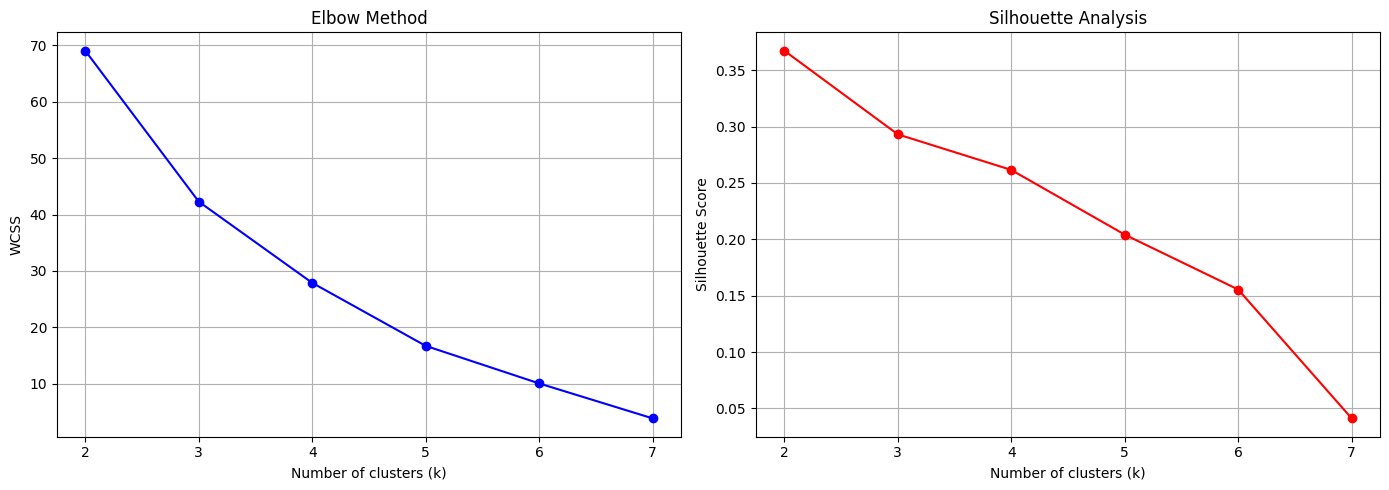

In [39]:
print(f"Number of samples: {len(all_countries_2007_2013_common)}")

K_range = range(2, 8)  # Maximum k=7 for 8 samples

inertias = []
silhouette_scores = []
wcss = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    wcss.append(kmeans.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('WCSS')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [40]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

all_countries_2007_2013_common = all_countries_2007_2013_common.copy()

all_countries_2007_2013_common.loc[:, 'Cluster'] = kmeans.fit_predict(X)

print(f"\n{'='*60}")
print(f"K-Means Clustering Results (k={optimal_k})")
print(f"{'='*60}\n")


K-Means Clustering Results (k=3)



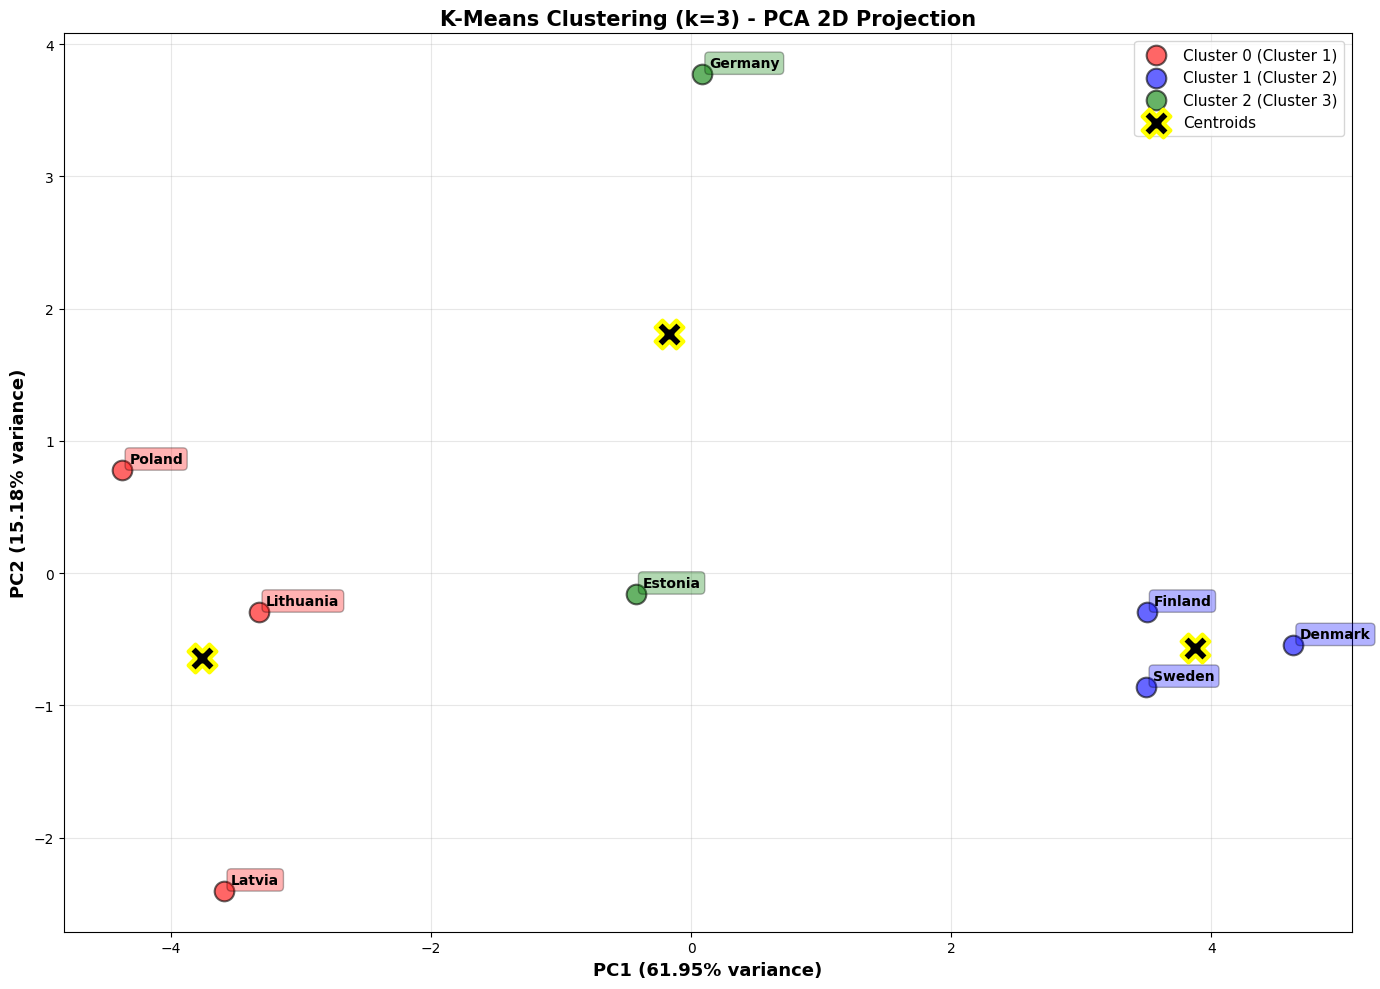


Total variance explained by 2 PCs: 77.13%


In [41]:
colors = ['red', 'blue', 'green']
cluster_country_names = ["Cluster 1", "Cluster 2", "Cluster 3"] 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(14, 10)) 
for i in range(optimal_k):
    cluster_indices = all_countries_2007_2013_common['Cluster'] == i
    plt.scatter(X_pca[cluster_indices, 0],
                X_pca[cluster_indices, 1],
                c=colors[i],
                label=f'Cluster {i} ({cluster_country_names[i]})',
                s=200, 
                alpha=0.6,
                edgecolors='black',
                linewidth=1.5)
    

    cluster_data = all_countries_2007_2013_common[cluster_indices]
    for idx, row in cluster_data.iterrows():
        country_idx = all_countries_2007_2013_common.index.get_loc(idx)
        plt.annotate(row['Country'], 
                    (X_pca[country_idx, 0], X_pca[country_idx, 1]),
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(5, 5), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))


centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=400, edgecolors='yellow',
            linewidths=3, label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection', 
          fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\nTotal variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [42]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

all_countries_2007_2013_common = all_countries_2007_2013_common.copy()

all_countries_2007_2013_common.loc[:, 'Cluster'] = cluster_labels

print("="*60)
print("CLUSTERING STATISTICS")
print("="*60)
print(f"\nNumber of clusters: {optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, cluster_labels):.3f}")

print("\n" + "-"*60)
print("Countries by Cluster:")
print("-"*60)
for cluster in range(optimal_k):
    countries = all_countries_2007_2013_common[all_countries_2007_2013_common['Cluster'] == cluster]['Country'].tolist()
    print(f"\nCluster {cluster} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Mean Values)")
print("="*60)

feature_cols = [col for col in all_countries_2007_2013_common.columns if col not in ['Country', 'Cluster']]

cluster_means = all_countries_2007_2013_common.groupby('Cluster')[feature_cols].mean()
print("\n", cluster_means.round(2))

print("\n" + "="*60)
print("DEFINING VARIABLES FOR EACH CLUSTER")
print("="*60)

overall_mean = all_countries_2007_2013_common[feature_cols].mean()
overall_std = all_countries_2007_2013_common[feature_cols].std()

for cluster in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - Distinctive Characteristics")
    print('='*60)
    
    cluster_data = all_countries_2007_2013_common[all_countries_2007_2013_common['Cluster'] == cluster][feature_cols]
    cluster_mean = cluster_data.mean()
    
    z_scores = (cluster_mean - overall_mean) / overall_std
    
    distinctive_features = z_scores.abs().sort_values(ascending=False)
    
    print("\nTop 5 Distinctive Variables:")
    for i, (feature, z_score) in enumerate(z_scores[distinctive_features.index[:5]].items(), 1):
        direction = "HIGH" if z_score > 0 else "LOW"
        print(f"{i}. {feature:10s}: {direction:4s} (z-score: {z_score:+.2f}, "
              f"mean: {cluster_mean[feature]:.2f} vs overall: {overall_mean[feature]:.2f})")



CLUSTERING STATISTICS

Number of clusters: 3
Inertia: 42.29
Silhouette Score: 0.293

------------------------------------------------------------
Countries by Cluster:
------------------------------------------------------------

Cluster 0 (3 countries):
  Poland, Lithuania, Latvia

Cluster 1 (3 countries):
  Denmark, Finland, Sweden

Cluster 2 (2 countries):
  Germany, Estonia

CLUSTER CHARACTERISTICS (Mean Values)

 Context   ROL    GE   COC    RQ   VAA    CPI   FOP    JI    IUI     PR    DI  \
Cluster                                                                        
0        0.81  0.79  0.46  1.08  0.90  56.67  0.97  0.96  68.83  56.67  7.24   
1        1.94  1.97  2.28  1.85  1.63  89.67  0.98  0.98  93.63  90.00  9.38   
2        1.42  1.24  1.49  1.49  1.27  73.00  0.98  0.95  82.10  87.50  7.96   

Context   DBP    DBD    SSB   DWCP   PMSI     PT     EC  
Cluster                                                  
0        6.00  24.67  84.96  71.30  58.89  79.15  71.16  
1  

In [43]:
cluster = all_countries_2007_2013_common["Cluster"]

In [44]:
X_df = pd.DataFrame(
    X, 
    columns=[f"{col}" for col in numeric_data.columns],
    index=all_countries_2007_2013_common.index
)

X_df['cluster'] = cluster.values



In [45]:
X_df.to_csv('Data/Context/all_2013.csv', index=True)

In [46]:
numeric_data = all_countries_2014_2020_common.drop(columns=['Country'])

In [47]:
labels = all_countries_2014_2020_common['Country']

In [48]:
sc = StandardScaler()

X = sc.fit_transform(numeric_data)

Number of samples: 8


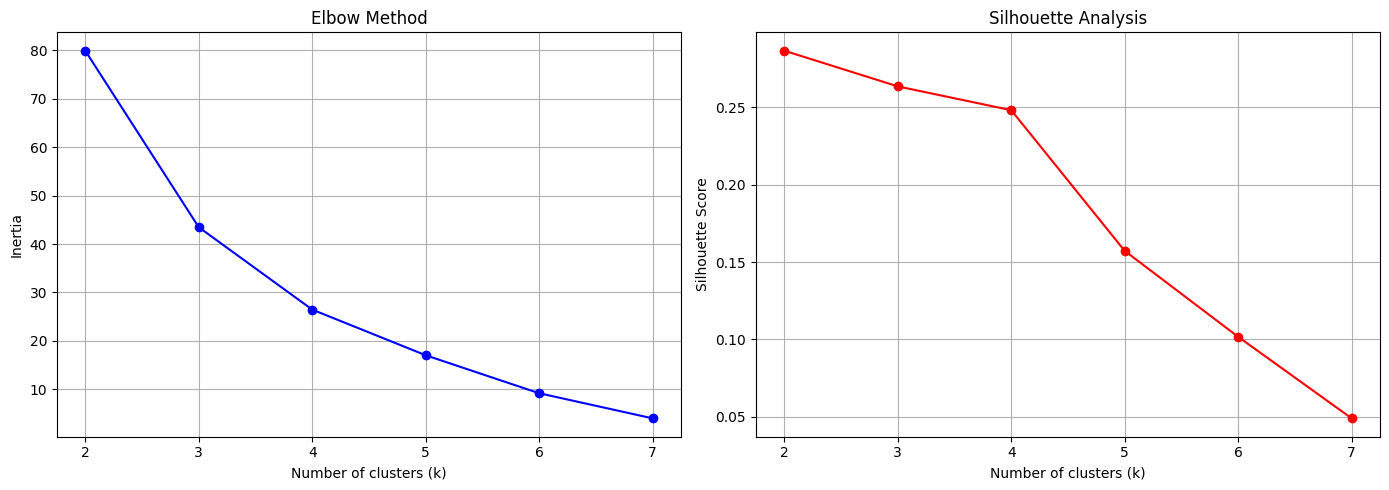

In [49]:
print(f"Number of samples: {len(all_countries_2014_2020_common)}")

K_range = range(2, 8)  # Maximum k=7 for 8 samples

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [50]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

all_countries_2014_2020_common = all_countries_2014_2020_common.copy()

all_countries_2014_2020_common.loc[:, 'Cluster'] = kmeans.fit_predict(X)

print(f"\n{'='*60}")
print(f"K-Means Clustering Results (k={optimal_k})")
print(f"{'='*60}\n")


K-Means Clustering Results (k=3)



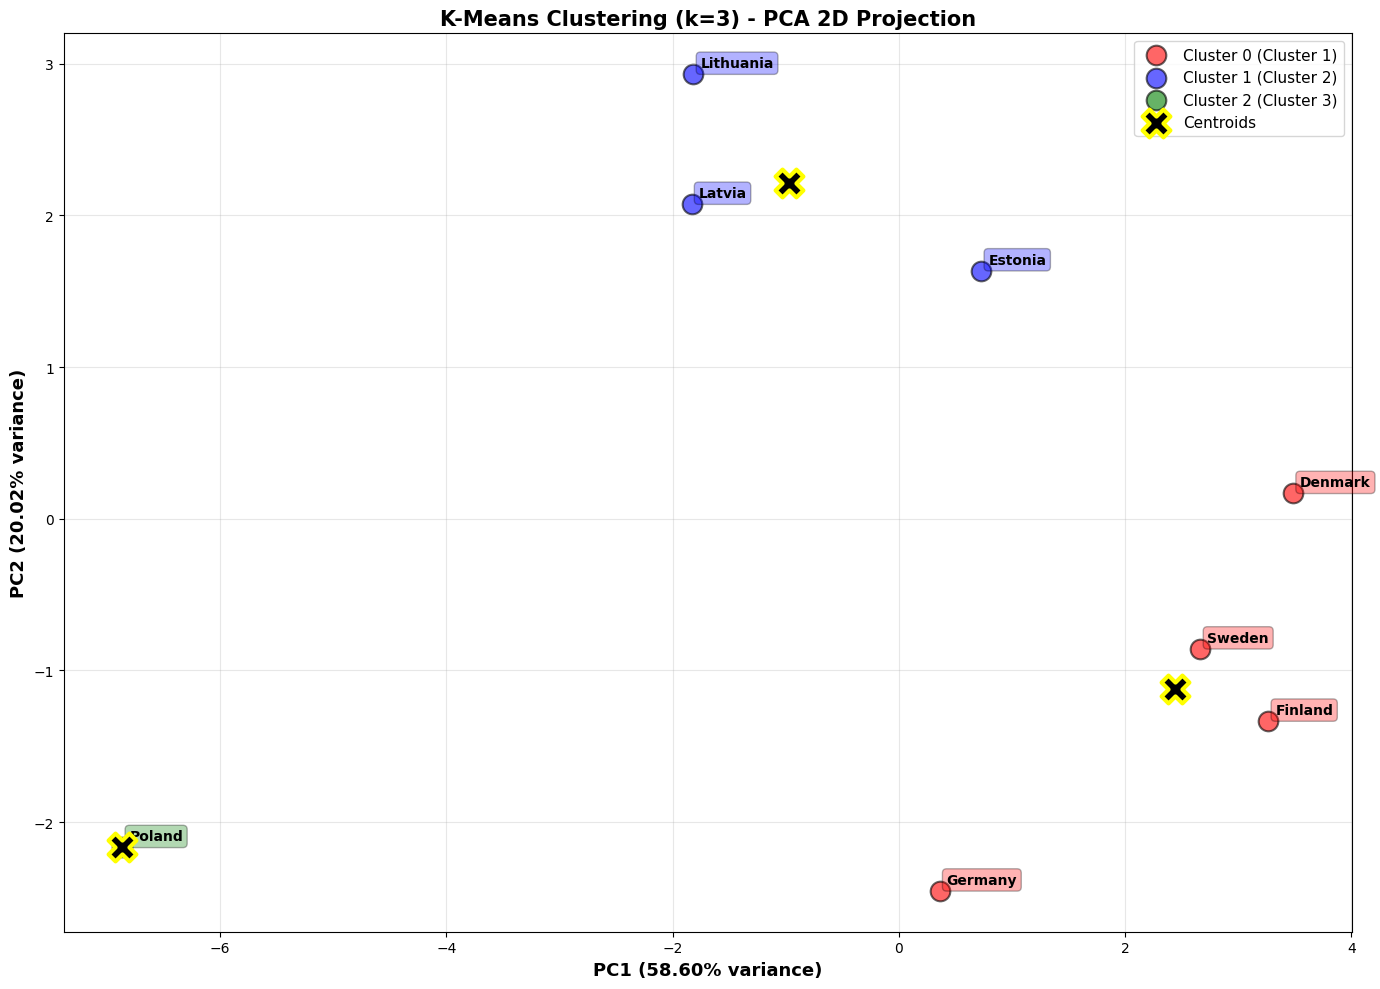


Total variance explained by 2 PCs: 78.61%


In [51]:
colors = ['red', 'blue', 'green']
cluster_country_names = ["Cluster 1", "Cluster 2", "Cluster 3"] 

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(14, 10)) 
for i in range(optimal_k):
    cluster_indices = all_countries_2014_2020_common['Cluster'] == i
    plt.scatter(X_pca[cluster_indices, 0],
                X_pca[cluster_indices, 1],
                c=colors[i],
                label=f'Cluster {i} ({cluster_country_names[i]})',
                s=200, 
                alpha=0.6,
                edgecolors='black',
                linewidth=1.5)
    

    cluster_data = all_countries_2014_2020_common[cluster_indices]
    for idx, row in cluster_data.iterrows():
        country_idx = all_countries_2014_2020_common.index.get_loc(idx)
        plt.annotate(row['Country'], 
                    (X_pca[country_idx, 0], X_pca[country_idx, 1]),
                    fontsize=10, 
                    fontweight='bold',
                    xytext=(5, 5), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.3))


centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=400, edgecolors='yellow',
            linewidths=3, label='Centroids', zorder=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection', 
          fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\nTotal variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

In [52]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

all_countries_2014_2020_common = all_countries_2014_2020_common.copy()

all_countries_2014_2020_common.loc[:, 'Cluster'] = cluster_labels

print("="*60)
print("CLUSTERING STATISTICS")
print("="*60)
print(f"\nNumber of clusters: {optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X, cluster_labels):.3f}")

print("\n" + "-"*60)
print("Countries by Cluster:")
print("-"*60)
for cluster in range(optimal_k):
    countries = all_countries_2014_2020_common[all_countries_2014_2020_common['Cluster'] == cluster]['Country'].tolist()
    print(f"\nCluster {cluster} ({len(countries)} countries):")
    print(f"  {', '.join(countries)}")

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Mean Values)")
print("="*60)

feature_cols = [col for col in all_countries_2014_2020_common.columns if col not in ['Country', 'Cluster']]

cluster_means = all_countries_2014_2020_common.groupby('Cluster')[feature_cols].mean()
print("\n", cluster_means.round(2))

print("\n" + "="*60)
print("DEFINING VARIABLES FOR EACH CLUSTER")
print("="*60)

overall_mean = all_countries_2014_2020_common[feature_cols].mean()
overall_std = all_countries_2014_2020_common[feature_cols].std()

for cluster in range(optimal_k):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - Distinctive Characteristics")
    print('='*60)
    
    cluster_data = all_countries_2014_2020_common[all_countries_2014_2020_common['Cluster'] == cluster][feature_cols]
    cluster_mean = cluster_data.mean()
    
    z_scores = (cluster_mean - overall_mean) / overall_std
    
    distinctive_features = z_scores.abs().sort_values(ascending=False)
    
    print("\nTop 5 Distinctive Variables:")
    for i, (feature, z_score) in enumerate(z_scores[distinctive_features.index[:5]].items(), 1):
        direction = "HIGH" if z_score > 0 else "LOW"
        print(f"{i}. {feature:10s}: {direction:4s} (z-score: {z_score:+.2f}, "
              f"mean: {cluster_mean[feature]:.2f} vs overall: {overall_mean[feature]:.2f})")



CLUSTERING STATISTICS

Number of clusters: 3
Inertia: 43.48
Silhouette Score: 0.264

------------------------------------------------------------
Countries by Cluster:
------------------------------------------------------------

Cluster 0 (4 countries):
  Denmark, Germany, Finland, Sweden

Cluster 1 (3 countries):
  Lithuania, Latvia, Estonia

Cluster 2 (1 countries):
  Poland

CLUSTER CHARACTERISTICS (Mean Values)

 Context   ROL    GE   COC    RQ   VAA   CPI   FOP    JI    IUI     PR    DI  \
Cluster                                                                       
0        1.78  1.68  2.08  1.72  1.50  84.5  0.97  0.97  93.25  87.00  9.07   
1        1.07  1.05  1.02  1.26  1.01  64.0  0.94  0.95  87.03  77.67  7.40   
2        0.52  0.32  0.62  0.85  0.62  56.0  0.71  0.57  83.20  63.00  6.85   

Context   DBP    DBD    SSB   DWCP   PMSI     PT     EC  
Cluster                                                  
0        5.25  10.81  89.92  79.13  66.50  87.37  69.67  
1       

In [53]:
cluster = all_countries_2014_2020_common["Cluster"]

In [54]:
X_df = pd.DataFrame(
    X, 
    columns=[f"{col}" for col in numeric_data.columns],
    index=all_countries_2014_2020_common.index
)

X_df['cluster'] = cluster.values


In [55]:
X_df.to_csv('Data/Context/all_2020.csv', index=True)